In [2]:
!pip install transitleastsquares


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # so Python can find phast_bootstrap.py
import phast_bootstrap

[phast_bootstrap] ready. Colab paths now resolve under: C:\Users\Swara Deshpande\exoplanet-detection-isro


In [4]:
from google.colab import drive
drive.mount('/content/drive')

[pipeline] mock drive.mount — using local repo


In [5]:
import pickle
import numpy as np
from transitleastsquares import transitleastsquares
import matplotlib.pyplot as plt


In [6]:
load_path = "/content/drive/MyDrive/exoplanet_pipeline/data/stage1_output.pkl"

with open(load_path, "rb") as f:
    stage1_data = pickle.load(f)

print(stage1_data.keys())

dict_keys(['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec', 'sector'])


In [7]:
time = stage1_data["time"]
flux = stage1_data["flux"]
flux_err = stage1_data["flux_err"]

tic_id = stage1_data["tic_id"]
crowdsap = stage1_data["crowdsap"]

ra = stage1_data["ra"]
dec = stage1_data["dec"]

print("TIC:", tic_id)
print("Cadences:", len(time))
print("CROWDSAP:", crowdsap)

TIC: 299798795
Cadences: 18256
CROWDSAP: 0.98880583


In [8]:
print(type(flux))
print(flux.dtype)

<class 'astropy.utils.masked.core.MaskedNDArray'>
float64


In [9]:
time = np.asarray(time)
flux = np.asarray(flux)
flux_err = np.asarray(flux_err)

In [10]:
print(time.min())
print(time.max())
print(np.isnan(flux).sum())

-2455674.7023847024
-2455646.8222008925
0


In [11]:
time_tls = time - np.min(time)

print("Min:", time_tls.min())
print("Max:", time_tls.max())

Min: 0.0
Max: 27.88018380990252


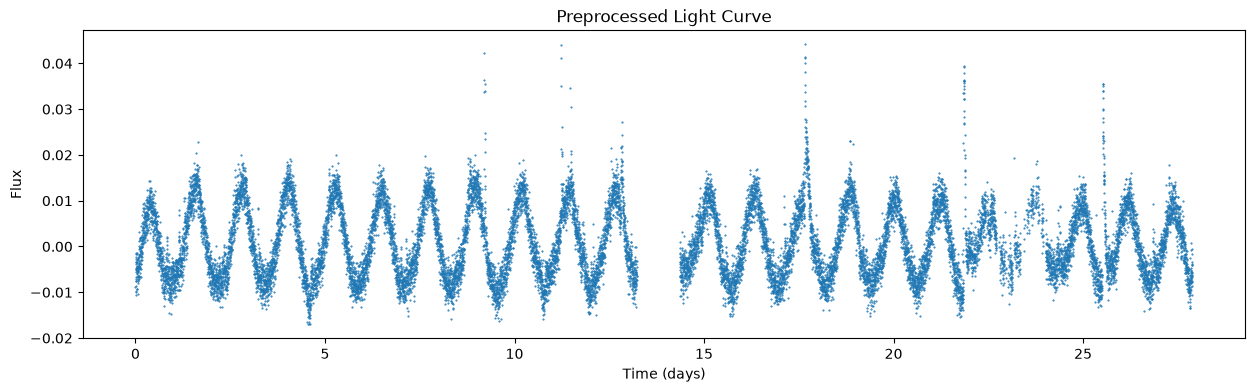

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(time_tls, flux, ".", markersize=1)

plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Preprocessed Light Curve")

plt.show()

In [13]:
results = transitleastsquares(time_tls, flux, flux_err).power()

print("Period   :", results.period)
print("SDE      :", results.SDE)
print("Depth    :", results.depth)
print("Duration :", results.duration)
print("T0       :", results.T0)

C:\Users\Swara Deshpande\exoplanet-detection-isro\.venv\Lib\site-packages\transitleastsquares\validate.py:31: UserWarning: Warning: The mean flux should be normalized to 1, but it was found to be 0.007432587929368518
  warnings.warn(text)


Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 9024 data points, 2541 periods from 0.601 to 13.882 days
Using all 12 CPU threads


  0%|          | 0/2541 periods | 00:00<?

  0%|          | 1/2541 periods | 00:10<7:40:07

  1%|          | 18/2541 periods | 00:10<18:20 

...

 98%|█████████▊| 2480/2541 periods | 00:17<00:00

 99%|█████████▉| 2520/2541 periods | 00:18<00:00

100%|██████████| 2541/2541 periods | 00:18<00:00

Searching for best T0 for period 2.28473 days


Period   : 2.2847303208257226
SDE      : 2.681362395995002
Depth    : -0.16790585498378952
Duration : 0.12531792437657716
T0       : 1.4122938525653819


In [14]:
# TLS expects flux normalized around 1.0.
# Stage 1 detrending centers the light curve around 0,
# so we shift it back before transit search.

from transitleastsquares import transitleastsquares

flux_tls = flux + 1
model = transitleastsquares(
    time_tls,
    flux_tls
)

results = model.power()

Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18255 data points, 2553 periods from 0.602 to 13.939 days
Using all 12 CPU threads


  0%|          | 0/2553 periods | 00:00<?

  0%|          | 1/2553 periods | 00:12<8:37:02

  0%|          | 5/2553 periods | 00:12<1:17:57

  1%|          | 13/2553 periods | 00:12<23:02 

...

 95%|█████████▌| 2433/2553 periods | 00:18<00:00

 97%|█████████▋| 2473/2553 periods | 00:18<00:00

 98%|█████████▊| 2512/2553 periods | 00:19<00:00

100%|██████████| 2553/2553 periods | 00:19<00:00

Searching for best T0 for period 3.69285 days


In [15]:
print("Period:", results.period)

print("Duration:", results.duration)

print("Depth:", results.depth)

print("T0:", results.T0)

print("Transit Count:", results.distinct_transit_count)

print("SNR:", results.snr)

print("Odd Even Mismatch:", results.odd_even_mismatch)

Period: 3.6928513446305002
Duration: 0.38028628888539967
Depth: 0.9919790361636929
T0: 0.9290402365729553
Transit Count: 8
SNR: 41.8507006267841
Odd Even Mismatch: 2.5683628533961396


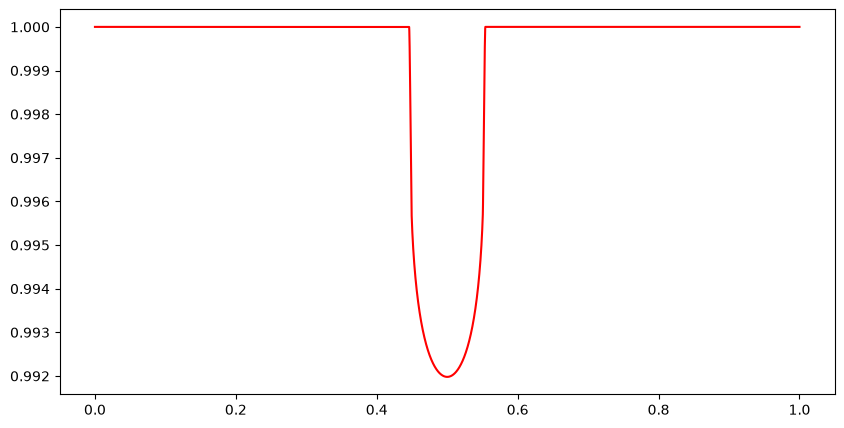

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(results.model_folded_phase,
         results.model_folded_model,
         color="red")

plt.show()

In [17]:
tls_features = {
    "period": float(results.period),
    "sde": float(results.SDE),
    "duration": float(results.duration),
    "t0": float(results.T0)
}

In [18]:
# ============================================================
# STAGE 2 OUTPUT EXPORT
# ============================================================

import os
import pickle

DATA_DIR = "/content/drive/MyDrive/exoplanet_pipeline/data"

os.makedirs(DATA_DIR, exist_ok=True)

stage2_data = {
    "period": float(results.period),
    "sde": float(results.SDE),
    "duration": float(results.duration),
    "t0": float(results.T0),

    "depth_tls": float(results.depth),
    "snr_tls": float(results.snr),

    "distinct_transit_count": int(
        results.distinct_transit_count
    ),

    "odd_even_mismatch_tls": float(
        results.odd_even_mismatch
    )
}

save_path = os.path.join(
    DATA_DIR,
    "stage2_output.pkl"
)

with open(save_path, "wb") as f:
    pickle.dump(stage2_data, f)

print("Stage 2 data saved successfully!")
print(save_path)
print(stage2_data)

Stage 2 data saved successfully!
/content/drive/MyDrive/exoplanet_pipeline/data\stage2_output.pkl
{'period': 3.6928513446305002, 'sde': 6.331901437838761, 'duration': 0.38028628888539967, 't0': 0.9290402365729553, 'depth_tls': 0.9919790361636929, 'snr_tls': 41.8507006267841, 'distinct_transit_count': 8, 'odd_even_mismatch_tls': 2.5683628533961396}
